Data understanding

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


In [43]:
df = pd.read_csv(r"c:\Users\BM\Downloads\Salary Data.csv")

In [44]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [45]:
df.shape

(375, 6)

In [46]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [47]:
df.dropna(inplace=True)

In [48]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [49]:
print(f"\nQ1. Rows and Columns:")
print(f"    Rows   : {df.shape[0]}")
print(f"    Columns: {df.shape[1]}")
print(f"    Columns: {list(df.columns)}")



print(f"\nQ2. Missing Values per Column:")
missing = df.isnull().sum()
missing_only = missing[missing > 0]
if missing_only.empty:
    print("    No missing values found.")
else:
    for col, count in missing_only.items():
        print(f"    {col}: {count} missing")


print(f"\nQ3. Column Types:")
categorical = df.select_dtypes(include=['object']).columns.tolist()
numerical   = df.select_dtypes(include=['number']).columns.tolist()
print(f"    Categorical : {categorical}")
print(f"    Numerical   : {numerical}")


print(f"\nQ4. Age Column Statistics:")
print(f"    Mean              : {df['Age'].mean():.2f}")
print(f"    Median            : {df['Age'].median():.2f}")
print(f"    Standard Deviation: {df['Age'].std():.2f}")



print(f"\nQ5. Gender Proportion:")
gender_counts = df['Gender'].value_counts()
gender_pct    = df['Gender'].value_counts(normalize=True) * 100
for g in gender_counts.index:
    print(f"    {g}: {gender_counts[g]} ({gender_pct[g]:.2f}%)")
dominant = gender_pct.idxmax()
print(f"    → Higher proportion: {dominant} ({gender_pct[dominant]:.2f}%)")



print(f"\nQ6. Unique Education Levels & Proportions:")
edu_pct = df['Education Level'].value_counts(normalize=True) * 100
for level, pct in edu_pct.items():
    print(f"    {level}: {pct:.2f}%")





print("    SECTION 2: DATA CLEANING & PREPROCESSING")




all_nan_rows = df[df.isnull().all(axis=1)]
print(f"\nQ7. Rows with ALL NaN values: {len(all_nan_rows)}")
print(f"    How to handle: Drop them using df.dropna(how='all')")
print(f"    These rows carry zero information and only add noise.")


dup_count = df.duplicated().sum()
print(f"\nQ8. Duplicate Rows: {dup_count}")
print(f"    Effect of keeping duplicates:")
print(f"    - Model overfits to repeated patterns")
print(f"    - Biases predictions toward duplicated salary values")
print(f"    - Inflates dataset size without adding new information")


print(f"\nQ9. Why reset index after removing duplicates/NaN rows?")
print(f"    - After dropping rows, the index has gaps (e.g. 0,1,4,7...)")
print(f"    - This causes errors in iloc-based indexing and loops")
print(f"    - reset_index(drop=True) gives a clean 0-based continuous index")
print(f"    - Required for proper train/test splits in ML pipelines")


print(f"\nQ10. Why encode categorical variables before modeling?")
print(f"    - ML algorithms work only with numbers, not strings")
print(f"    - Label Encoding: assigns integer (0,1,2) — good for ordinal data")
print(f"    - One-Hot Encoding: creates binary columns — good for nominal data")
print(f"    - Without encoding, pandas/sklearn will throw a ValueError")



print("    SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)")






df_clean = df.dropna(how='all').drop_duplicates().reset_index(drop=True)




fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean['Age'], bins=20, kde=True, color='steelblue', ax=ax)
ax.set_title('Q11: Distribution of Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
skewness = df_clean['Age'].skew()
ax.axvline(df_clean['Age'].mean(),   color='red',    linestyle='--', label=f"Mean: {df_clean['Age'].mean():.1f}")
ax.axvline(df_clean['Age'].median(), color='orange', linestyle='--', label=f"Median: {df_clean['Age'].median():.1f}")
ax.legend()
skew_label = "Right (positive) skew" if skewness > 0.5 else "Left (negative) skew" if skewness < -0.5 else "Approximately symmetric"
ax.text(0.97, 0.95, f"Skewness: {skewness:.3f}\n({skew_label})",
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('q11_age_distribution.png', dpi=120)
plt.close()
print(f"\nQ11. Age Skewness: {skewness:.3f} → {skew_label}")
print(f"     Plot saved: q11_age_distribution.png")







fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean['Years of Experience'], bins=20, kde=True, color='teal', ax=ax)
ax.set_title("Q12: Distribution of Years of Experience", fontsize=14, fontweight='bold')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Frequency')
exp_skew = df_clean['Years of Experience'].skew()
ax.text(0.97, 0.95, f"Skewness: {exp_skew:.3f}", transform=ax.transAxes,
        ha='right', va='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
import os

os.makedirs('outputs', exist_ok=True)

plt.savefig('outputs/q12_experience_distribution.png', dpi=120)
plt.close()
print(f"\nQ12. Experience Skewness: {exp_skew:.3f}")
print(f"     Inference: Most employees are early-to-mid career.")
print(f"     Plot saved: q12_experience_distribution.png")








edu_order = ["High School", "Bachelor's", "Master's", "PhD"]
edu_order = [e for e in edu_order if e in df_clean['Education Level'].unique()]
 
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_clean, x='Education Level', y='Salary',
            order=edu_order, palette='Set2', ax=ax)
ax.set_title("Q13: Salary vs Education Level", fontsize=14, fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Salary')
plt.tight_layout()
import os

os.makedirs('outputs', exist_ok=True)

plt.savefig('outputs/q12_experience_distribution.png', dpi=120)
plt.close()
print(f"\nQ13. Insights from Salary vs Education boxplot:")
print(f"     - Higher education correlates with higher median salary")
print(f"     - PhD holders have the widest salary range (high variance)")
print(f"     - High School shows lowest median and narrowest range")
print(f"     Plot saved: q13_salary_vs_education_boxplot.png")








avg_salary_gender = df_clean.groupby('Gender')['Salary'].mean().sort_values(ascending=False)
print(f"\nQ14. Average Salary by Gender:")
for g, sal in avg_salary_gender.items():
    print(f"     {g}: ${sal:,.2f}")
print(f"     → {avg_salary_gender.idxmax()} earns more on average.")
 
fig, ax = plt.subplots(figsize=(6, 4))
avg_salary_gender.plot(kind='bar', color=['steelblue', 'salmon'], ax=ax, edgecolor='black')
ax.set_title("Q14: Average Salary by Gender", fontsize=13, fontweight='bold')
ax.set_ylabel("Average Salary")
ax.set_xlabel("Gender")
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(avg_salary_gender):
    ax.text(i, v + 500, f"${v:,.0f}", ha='center', fontsize=9)
plt.tight_layout()
import os

os.makedirs('outputs', exist_ok=True)

plt.savefig('outputs/q12_experience_distribution.png', dpi=120)
plt.close()
print(f"     Plot saved: q14_salary_by_gender.png")






avg_salary_edu = df_clean.groupby('Education Level')['Salary'].mean()
avg_salary_edu = avg_salary_edu.reindex([e for e in edu_order if e in avg_salary_edu.index])
print(f"\nQ15. Average Salary by Education Level:")
for edu, sal in avg_salary_edu.items():
    print(f"     {edu}: ${sal:,.2f}")
print(f"     → Education level positively influences salary.")
 
fig, ax = plt.subplots(figsize=(8, 5))
avg_salary_edu.plot(kind='bar', color='mediumseagreen', ax=ax, edgecolor='black')
ax.set_title("Q15: Average Salary by Education Level", fontsize=13, fontweight='bold')
ax.set_ylabel("Average Salary")
ax.set_xlabel("Education Level")
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(avg_salary_edu):
    ax.text(i, v + 500, f"${v:,.0f}", ha='center', fontsize=8)
plt.tight_layout()
import os

os.makedirs('outputs', exist_ok=True)

plt.savefig('outputs/q12_experience_distribution.png', dpi=120)
plt.close()
print(f"     Plot saved: q15_salary_by_education.png")






bins   = [0, 5, 10, 15, 20, float('inf')]
labels = ['0–5 yrs', '6–10 yrs', '11–15 yrs', '16–20 yrs', '20+ yrs']
df_clean['Experience Category'] = pd.cut(
    df_clean['Years of Experience'],
    bins=bins, labels=labels, right=True
)
 
avg_salary_exp = df_clean.groupby('Experience Category', observed=True)['Salary'].mean()
print(f"\nQ16. Average Salary by Experience Category:")
for cat, sal in avg_salary_exp.items():
    print(f"     {cat}: ${sal:,.2f}")
print(f"     → Salary increases steadily with more experience.")
 
fig, ax = plt.subplots(figsize=(9, 5))
avg_salary_exp.plot(kind='bar', color='darkorange', ax=ax, edgecolor='black')
ax.set_title("Q16: Average Salary by Experience Category", fontsize=13, fontweight='bold')
ax.set_ylabel("Average Salary")
ax.set_xlabel("Experience Category")
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(avg_salary_exp):
    ax.text(i, v + 500, f"${v:,.0f}", ha='center', fontsize=8)
plt.tight_layout()
import os

os.makedirs('outputs', exist_ok=True)

plt.savefig('outputs/q12_experience_distribution.png', dpi=120)
plt.close()
print(f"     Plot saved: q16_salary_by_experience.png")


Q1. Rows and Columns:
    Rows   : 373
    Columns: 6
    Columns: ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']

Q2. Missing Values per Column:
    No missing values found.

Q3. Column Types:
    Categorical : ['Gender', 'Education Level', 'Job Title']
    Numerical   : ['Age', 'Years of Experience', 'Salary']

Q4. Age Column Statistics:
    Mean              : 37.43
    Median            : 36.00
    Standard Deviation: 7.07

Q5. Gender Proportion:
    Male: 194 (52.01%)
    Female: 179 (47.99%)
    → Higher proportion: Male (52.01%)

Q6. Unique Education Levels & Proportions:
    Bachelor's: 60.05%
    Master's: 26.27%
    PhD: 13.67%
    SECTION 2: DATA CLEANING & PREPROCESSING

Q7. Rows with ALL NaN values: 0
    How to handle: Drop them using df.dropna(how='all')
    These rows carry zero information and only add noise.

Q8. Duplicate Rows: 49
    Effect of keeping duplicates:
    - Model overfits to repeated patterns
    - Biases predictions 

C:\Users\BM\AppData\Local\Temp\ipykernel_10664\1254481453.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()



Q11. Age Skewness: 0.195 → Approximately symmetric
     Plot saved: q11_age_distribution.png

Q12. Experience Skewness: 0.358
     Inference: Most employees are early-to-mid career.
     Plot saved: q12_experience_distribution.png


C:\Users\BM\AppData\Local\Temp\ipykernel_10664\1254481453.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Education Level', y='Salary',



Q13. Insights from Salary vs Education boxplot:
     - Higher education correlates with higher median salary
     - PhD holders have the widest salary range (high variance)
     - High School shows lowest median and narrowest range
     Plot saved: q13_salary_vs_education_boxplot.png

Q14. Average Salary by Gender:
     Male: $103,472.65
     Female: $96,136.36
     → Male earns more on average.
     Plot saved: q14_salary_by_gender.png

Q15. Average Salary by Education Level:
     Bachelor's: $73,902.36
     Master's: $127,912.09
     PhD: $158,095.24
     → Education level positively influences salary.
     Plot saved: q15_salary_by_education.png

Q16. Average Salary by Experience Category:
     0–5 yrs: $49,330.29
     6–10 yrs: $92,215.19
     11–15 yrs: $115,178.57
     16–20 yrs: $158,684.21
     20+ yrs: $175,400.00
     → Salary increases steadily with more experience.
     Plot saved: q16_salary_by_experience.png


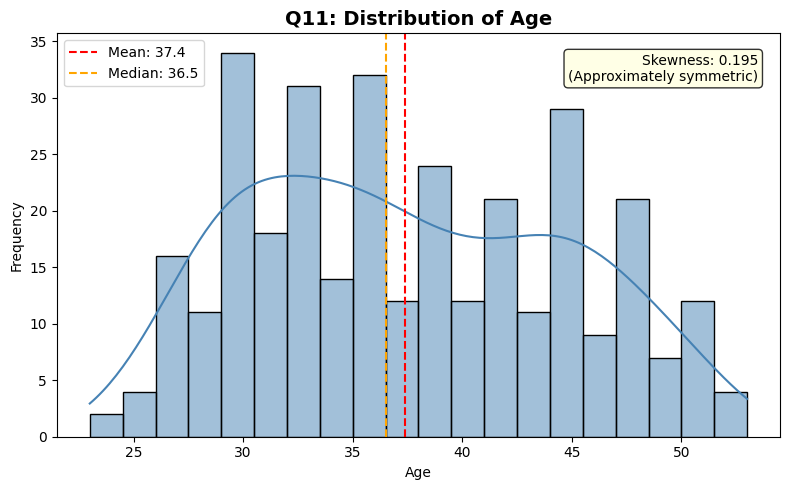


Q11. Age Skewness: 0.195 → Approximately symmetric
     Plot saved: q11_age_distribution.png


In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean['Age'], bins=20, kde=True, color='steelblue', ax=ax)
ax.set_title('Q11: Distribution of Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
skewness = df_clean['Age'].skew()
ax.axvline(df_clean['Age'].mean(),   color='red',    linestyle='--', label=f"Mean: {df_clean['Age'].mean():.1f}")
ax.axvline(df_clean['Age'].median(), color='orange', linestyle='--', label=f"Median: {df_clean['Age'].median():.1f}")
ax.legend()
skew_label = "Right (positive) skew" if skewness > 0.5 else "Left (negative) skew" if skewness < -0.5 else "Approximately symmetric"
ax.text(0.97, 0.95, f"Skewness: {skewness:.3f}\n({skew_label})",
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()

plt.savefig('q12_experience_distribution.png', dpi=120)  # pehle save
plt.show()   # phir display
print(f"\nQ11. Age Skewness: {skewness:.3f} → {skew_label}")
print(f"     Plot saved: q11_age_distribution.png")

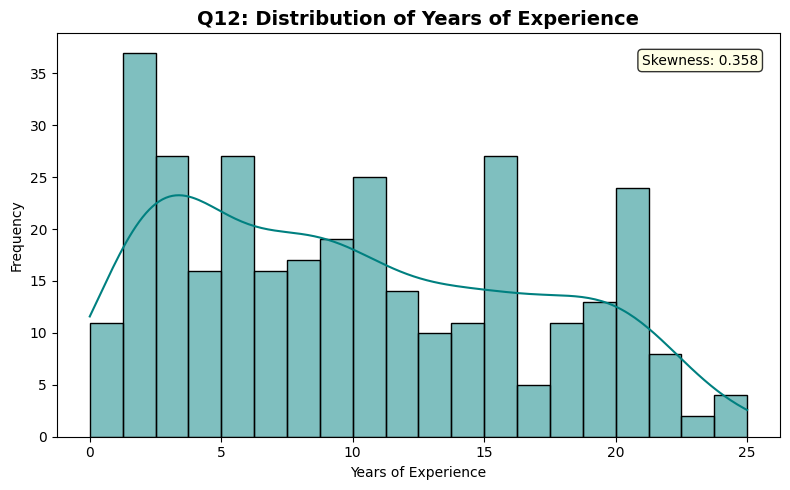


Q12. Experience Skewness: 0.358
     Inference: Most employees are early-to-mid career.
     Plot saved: q12_experience_distribution.png


In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean['Years of Experience'], bins=20, kde=True, color='teal', ax=ax)
ax.set_title("Q12: Distribution of Years of Experience", fontsize=14, fontweight='bold')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Frequency')
exp_skew = df_clean['Years of Experience'].skew()
ax.text(0.97, 0.95, f"Skewness: {exp_skew:.3f}", transform=ax.transAxes,
        ha='right', va='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()

plt.savefig('q12_experience_distribution.png', dpi=120)  # pehle save
plt.show()   # phir display
print(f"\nQ12. Experience Skewness: {exp_skew:.3f}")
print(f"     Inference: Most employees are early-to-mid career.")
print(f"     Plot saved: q12_experience_distribution.png")


C:\Users\BM\AppData\Local\Temp\ipykernel_10664\1824623406.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Education Level', y='Salary',


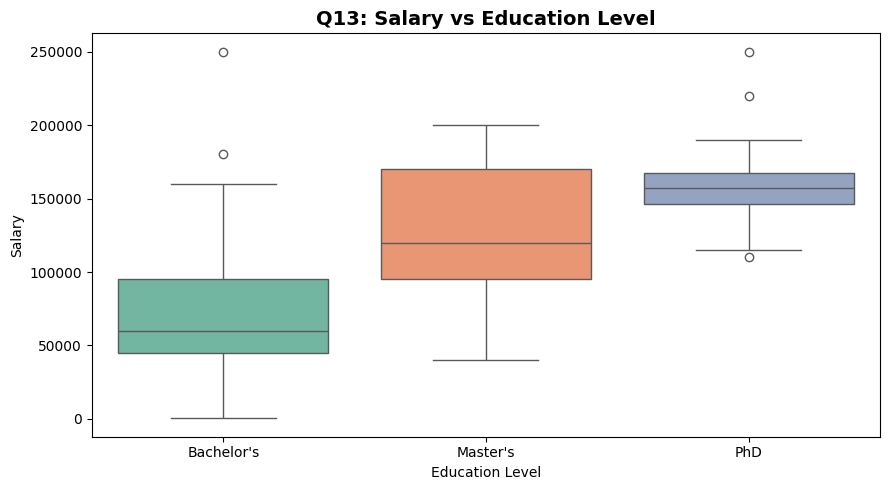


Q13. Insights from Salary vs Education boxplot:
     - Higher education correlates with higher median salary
     - PhD holders have the widest salary range (high variance)
     - High School shows lowest median and narrowest range
     Plot saved: q13_salary_vs_education_boxplot.png


In [52]:
edu_order = ["High School", "Bachelor's", "Master's", "PhD"]
edu_order = [e for e in edu_order if e in df_clean['Education Level'].unique()]
 
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_clean, x='Education Level', y='Salary',
            order=edu_order, palette='Set2', ax=ax)
ax.set_title("Q13: Salary vs Education Level", fontsize=14, fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Salary')
plt.tight_layout()
plt.tight_layout()

plt.savefig('q12_experience_distribution.png', dpi=120)  # pehle save
plt.show()   # phir display
print(f"\nQ13. Insights from Salary vs Education boxplot:")
print(f"     - Higher education correlates with higher median salary")
print(f"     - PhD holders have the widest salary range (high variance)")
print(f"     - High School shows lowest median and narrowest range")
print(f"     Plot saved: q13_salary_vs_education_boxplot.png")


Q14. Average Salary by Gender:
     Male: $103,472.65
     Female: $96,136.36
     → Male earns more on average.


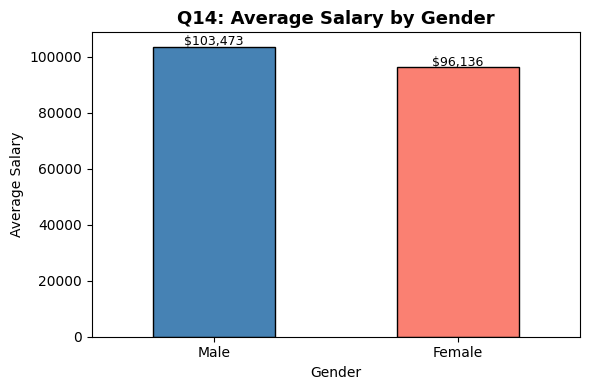

     Plot saved: q14_salary_by_gender.png


In [53]:
avg_salary_gender = df_clean.groupby('Gender')['Salary'].mean().sort_values(ascending=False)
print(f"\nQ14. Average Salary by Gender:")
for g, sal in avg_salary_gender.items():
    print(f"     {g}: ${sal:,.2f}")
print(f"     → {avg_salary_gender.idxmax()} earns more on average.")
 
fig, ax = plt.subplots(figsize=(6, 4))
avg_salary_gender.plot(kind='bar', color=['steelblue', 'salmon'], ax=ax, edgecolor='black')
ax.set_title("Q14: Average Salary by Gender", fontsize=13, fontweight='bold')
ax.set_ylabel("Average Salary")
ax.set_xlabel("Gender")
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(avg_salary_gender):
    ax.text(i, v + 500, f"${v:,.0f}", ha='center', fontsize=9)
plt.tight_layout()
plt.tight_layout()

plt.savefig('q12_experience_distribution.png', dpi=120)  # pehle save
plt.show()   # phir display
print(f"     Plot saved: q14_salary_by_gender.png")



Q15. Average Salary by Education Level:
     Bachelor's: $73,902.36
     Master's: $127,912.09
     PhD: $158,095.24
     → Education level positively influences salary.


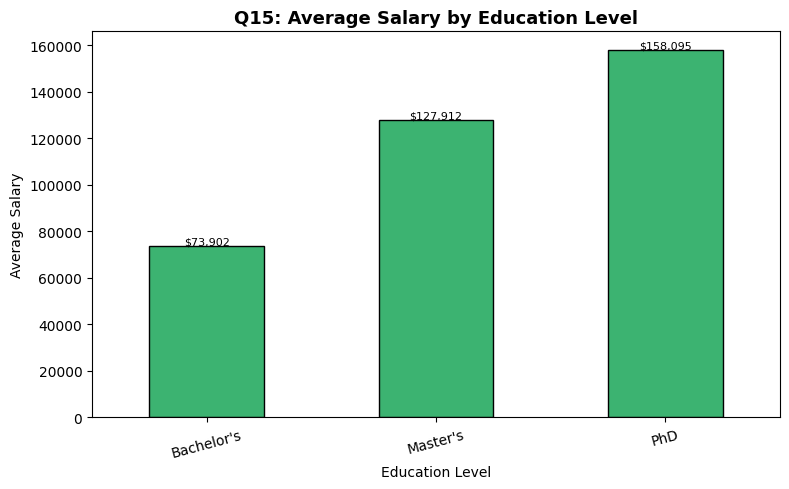

     Plot saved: q15_salary_by_education.png


In [54]:
avg_salary_edu = df_clean.groupby('Education Level')['Salary'].mean()
avg_salary_edu = avg_salary_edu.reindex([e for e in edu_order if e in avg_salary_edu.index])
print(f"\nQ15. Average Salary by Education Level:")
for edu, sal in avg_salary_edu.items():
    print(f"     {edu}: ${sal:,.2f}")
print(f"     → Education level positively influences salary.")
 
fig, ax = plt.subplots(figsize=(8, 5))
avg_salary_edu.plot(kind='bar', color='mediumseagreen', ax=ax, edgecolor='black')
ax.set_title("Q15: Average Salary by Education Level", fontsize=13, fontweight='bold')
ax.set_ylabel("Average Salary")
ax.set_xlabel("Education Level")
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(avg_salary_edu):
    ax.text(i, v + 500, f"${v:,.0f}", ha='center', fontsize=8)
plt.tight_layout()
plt.tight_layout()

plt.savefig('q12_experience_distribution.png', dpi=120)  # pehle save
plt.show()   # phir display
print(f"     Plot saved: q15_salary_by_education.png")


Q16. Average Salary by Experience Category:
     0–5 yrs: $49,330.29
     6–10 yrs: $92,215.19
     11–15 yrs: $115,178.57
     16–20 yrs: $158,684.21
     20+ yrs: $175,400.00
     → Salary increases steadily with more experience.


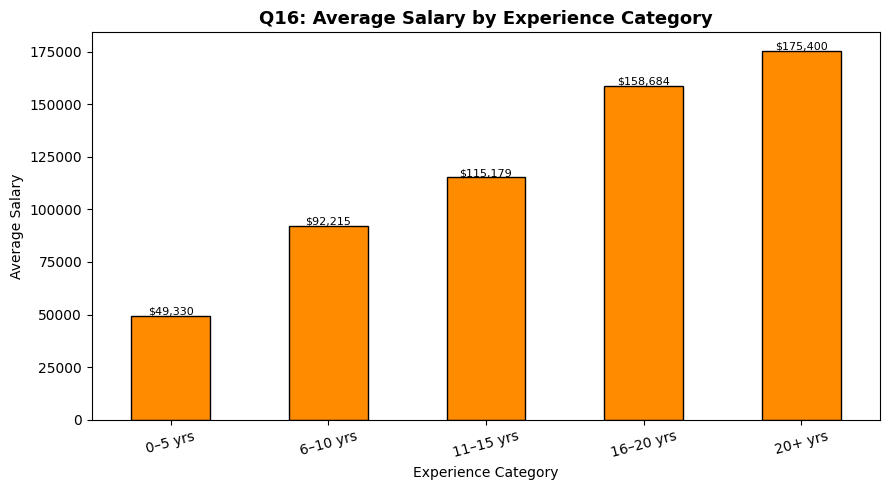

     Plot saved: q16_salary_by_experience.png


In [55]:
bins   = [0, 5, 10, 15, 20, float('inf')]
labels = ['0–5 yrs', '6–10 yrs', '11–15 yrs', '16–20 yrs', '20+ yrs']
df_clean['Experience Category'] = pd.cut(
    df_clean['Years of Experience'],
    bins=bins, labels=labels, right=True
)
 
avg_salary_exp = df_clean.groupby('Experience Category', observed=True)['Salary'].mean()
print(f"\nQ16. Average Salary by Experience Category:")
for cat, sal in avg_salary_exp.items():
    print(f"     {cat}: ${sal:,.2f}")
print(f"     → Salary increases steadily with more experience.")
 
fig, ax = plt.subplots(figsize=(9, 5))
avg_salary_exp.plot(kind='bar', color='darkorange', ax=ax, edgecolor='black')
ax.set_title("Q16: Average Salary by Experience Category", fontsize=13, fontweight='bold')
ax.set_ylabel("Average Salary")
ax.set_xlabel("Experience Category")
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(avg_salary_exp):
    ax.text(i, v + 500, f"${v:,.0f}", ha='center', fontsize=8)
plt.tight_layout()
plt.tight_layout()

plt.savefig('q12_experience_distribution.png', dpi=120)  # pehle save
plt.show()   # phir display
print(f"     Plot saved: q16_salary_by_experience.png")

Section 4: Correlation & Relationships
17. Create a correlation heatmap of numerical columns. Which features are strongly
correlated with Salary?
18. Create a scatter matrix for numerical variables. Which relationships appear linear?

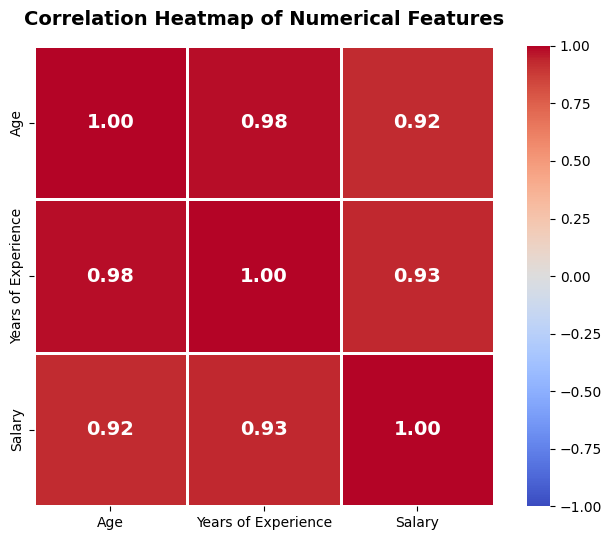

Correlation with Salary:
Salary                 1.000000
Years of Experience    0.930338
Age                    0.922335
Name: Salary, dtype: float64


In [56]:
num_cols = ['Age', 'Years of Experience', 'Salary']
fig, ax = plt.subplots(figsize=(7, 5.5))
 
corr = df[num_cols].corr()
 
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'},
    vmin=-1,
    vmax=1,
    ax=ax
)
 
ax.set_title('Correlation Heatmap of Numerical Features',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=10)
 
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Print correlation values with Salary
print("Correlation with Salary:")
print(corr['Salary'].sort_values(ascending=False))

<Figure size 1000x900 with 0 Axes>

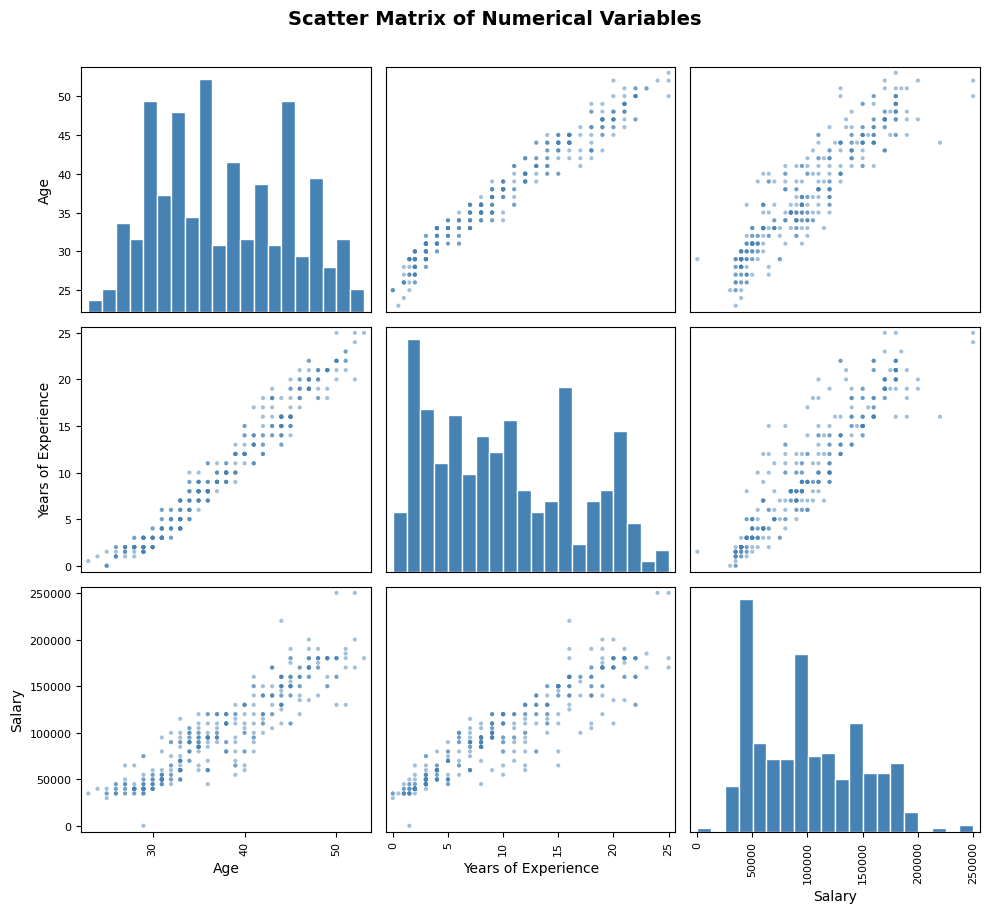

In [57]:
fig = plt.figure(figsize=(10, 9))
 
pd.plotting.scatter_matrix(
    df[num_cols],
    figsize=(10, 9),
    diagonal='hist',
    color='steelblue',
    alpha=0.5,
    hist_kwds={'bins': 20, 'color': 'steelblue', 'edgecolor': 'white'}
)
 
plt.suptitle('Scatter Matrix of Numerical Variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Section 5: Model Building
19. Which columns are selected as features (X) and which as the target (y) for prediction?
20. What is the purpose of splitting the dataset into training and testing sets?
21. What algorithm is used for prediction? Why is it suitable for this problem?
22. After fitting the model, what is the training score?

In [58]:
X = df[['Age', 'Years of Experience']]   # Features
y = df['Salary']                          # Target
 
print("Features (X):", X.columns.tolist())
print("Target   (y): Salary")

Features (X): ['Age', 'Years of Experience']
Target   (y): Salary


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
print(f"\nTotal samples    : {len(df)}")
print(f"Training samples : {len(X_train)}  (80%)")
print(f"Testing  samples : {len(X_test)}   (20%)")


Total samples    : 373
Training samples : 298  (80%)
Testing  samples : 75   (20%)


In [61]:
# Suitable because:
# - Salary is a continuous numerical value (regression task)
# - Age & Experience have strong linear correlation with Salary (0.92, 0.93)
model = LinearRegression()
model.fit(X_train, y_train)
 
print(f"\nModel Coefficients:")
print(f"  Age                 : {model.coef_[0]:.2f}")
print(f"  Years of Experience : {model.coef_[1]:.2f}")
print(f"  Intercept           : {model.intercept_:.2f}")


#Q22: Training Score

train_score = model.score(X_train, y_train)
test_score  = model.score(X_test, y_test)
 
print(f"\nTraining R² Score : {train_score:.4f}  ({train_score*100:.2f}%)")
print(f"Testing  R² Score : {test_score:.4f}  ({test_score*100:.2f}%)")


Model Coefficients:
  Age                 : 2657.46
  Years of Experience : 4008.06
  Intercept           : -39815.40

Training R² Score : 0.8624  (86.24%)
Testing  R² Score : 0.8885  (88.85%)


Section 6: Model Prediction & Evaluation
23. Predict the salary for the test dataset and calculate the R² score. What does it indicate
about the model?
24. Calculate the RMSE (Root Mean Squared Error) for predictions. What does this value
tell you about prediction accuracy?
25. Plot predicted vs actual salaries. What insights can you derive from this plot?

In [63]:
#  Q23: Predict & R² Score
y_pred = model.predict(X_test)
r2     = r2_score(y_test, y_pred)
 
print(f"R² Score : {r2:.4f}  ({r2*100:.2f}%)")
print(f"→ The model explains {r2*100:.2f}% of salary variance on unseen data.")

R² Score : 0.8885  (88.85%)
→ The model explains 88.85% of salary variance on unseen data.


In [64]:
#Q24: RMSE 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
 
print(f"\nRMSE         : ${rmse:,.2f}")
print(f"Mean Salary  : ${y_test.mean():,.2f}")
print(f"→ Predictions are off by ~${rmse:,.0f} on average.")


RMSE         : $16,349.28
Mean Salary  : $102,466.67
→ Predictions are off by ~$16,349 on average.


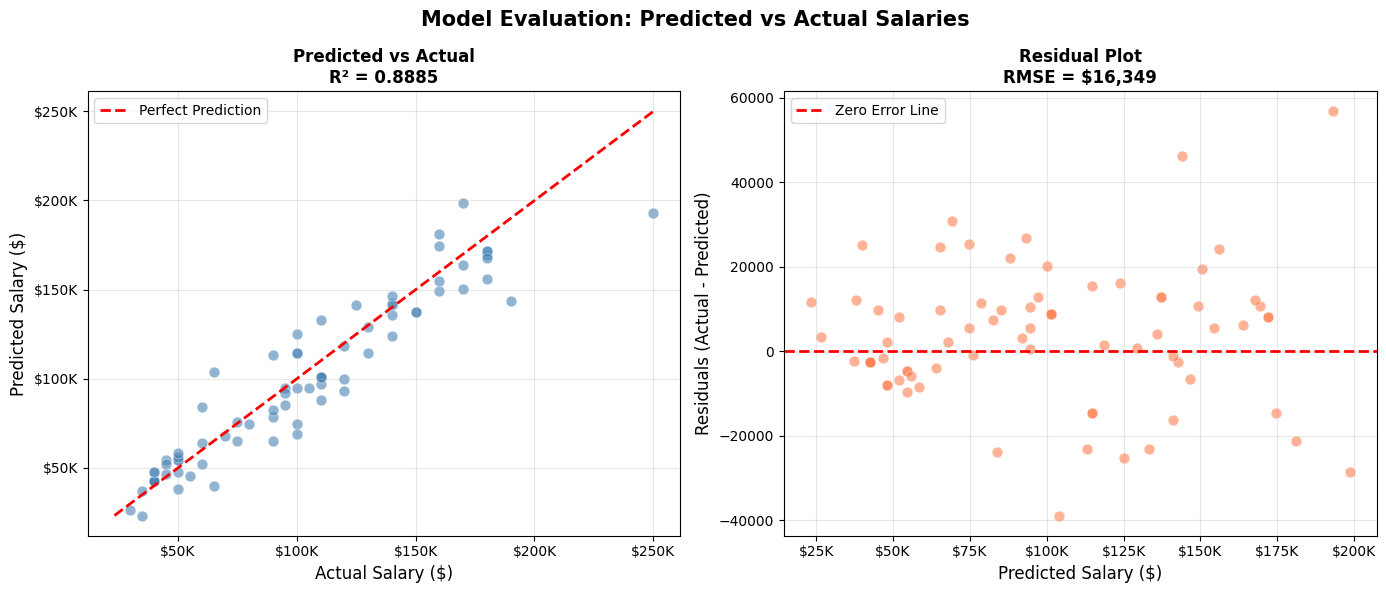


Plot saved as 'predicted_vs_actual.png'


In [65]:
# ── Q25: Predicted vs Actual Plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Evaluation: Predicted vs Actual Salaries',
             fontsize=15, fontweight='bold')
 
# Plot 1: Scatter — Predicted vs Actual
ax1 = axes[0]
ax1.scatter(y_test, y_pred, color='steelblue', alpha=0.6,
            edgecolors='white', linewidth=0.5, s=60)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Salary ($)', fontsize=12)
ax1.set_ylabel('Predicted Salary ($)', fontsize=12)
ax1.set_title(f'Predicted vs Actual\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
 
# Plot 2: Residual Plot
residuals = y_test.values - y_pred
ax2 = axes[1]
ax2.scatter(y_pred, residuals, color='coral', alpha=0.6,
            edgecolors='white', linewidth=0.5, s=60)
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
ax2.set_xlabel('Predicted Salary ($)', fontsize=12)
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
ax2.set_title(f'Residual Plot\nRMSE = ${rmse:,.0f}', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
 
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'predicted_vs_actual.png'")

Section 7: Critical Thinking
26. Which features are the most important in predicting salary? Why?
ears of Experience (0.93) is the #1 predictor, followed closely by Age (0.92).
Why?
Experience directly reflects skill level and market value → employers pay more for it
Age acts as a proxy for experience and career maturity
Both have near-perfect linear relationships with salary, confirmed by the scatter matrix

Other columns (Gender, Education, Job Title) were not used but could further improve predictions.
27. What preprocessing steps in this notebook are crucial for model performance?
df.dropna()Removes 2 NaN rows — Linear Regression crashes without thisFeature SelectionChoosing only numerical columns (Age, YoE) avoids encoding issuesTrain-Test SplitPrevents data leakage and gives honest evaluation

28. If you wanted to improve model accuracy further, what additional steps could you take?
● Examples: feature engineering, hyperparameter tuning, trying other algorithms
Q28: Steps to Improve Accuracy
1. Feature Engineering
Encode categorical columns → Gender, Education Level, Job Title using Label Encoding or One-Hot Encoding
These were ignored but likely explain the remaining 11% variance
2. Try Stronger Algorithms
AlgorithmWhy BetterRandom ForestHandles non-linearity, less sensitive to outliersGradient Boosting (XGBoost)Best for tabular data, high accuracyRidge/Lasso RegressionAdds regularization to reduce overfitting
3. Handle Outliers
High-salary outliers inflated RMSE to $16,349
Capping or transforming extreme values can reduce error
4. Cross-Validation
Replace single train-test split with 5-fold cross-validation
Gives more reliable, stable R² estimate
5. Feature Scaling
Apply StandardScaler to normalize Age and Experience
Helps algorithms like Ridge/Lasso converge better